## Лабораторная работа №1

Меркулов Роман Александрович 9 группа


### 1. Подготовка
Для начала определимся, что такое гармонический сигнал. Его функция

s(t) = A * sin(2pi * f * t)

t - время в секундах

f - частота в герцах

A - амплитуда

Для задания функции однополярного меандра можем воспользоваться следующим, возьмем практически ту же функцию, что и у нас сейчас, но сделаем так, чтобы при положительном синусе функция давала 1 * A, при отрицательном 0, то есть:

A · 0.5 * (1 + sign( 2pi * f * t ) ))

t - тоже время в секундах

f - та же частота в герцах

A - та же амплитуда






In [63]:
import numpy as np


def harmonic_signal(f, t, A=1.0):
    return A * np.sin(2 * np.pi * f * t)

def digital_signal(f, t, A=1.0):
    return A * 0.5 * (1 + np.sign( np.sin( 2 * np.pi * f * t ) ))

### 2. Построение графиков гармонического и цифрового сигнала с частотами 1,2,4,8 герц
Определим параметры

fs - частота дискретизации (в нашем случае, по теореме Котельникова fs > 2 * f_max(а в нашем случае это 8), мы могли взять и меньшую частоту)

time - время эксперимента

A - амплитуда сигнала

freqs - частоты наших сигналов

In [64]:
fs = 1000
time = 1.0
A = 1.0
freqs = [1, 2, 4, 8]
times = np.arange(0, time, 1/fs)

Теперь строим графики

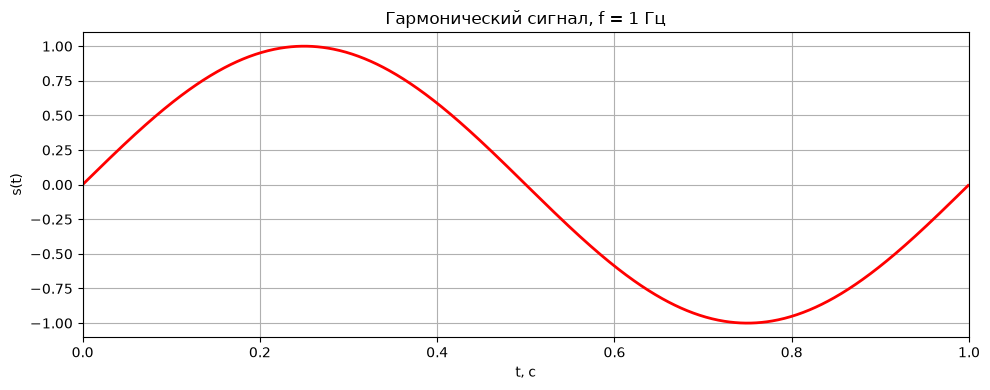

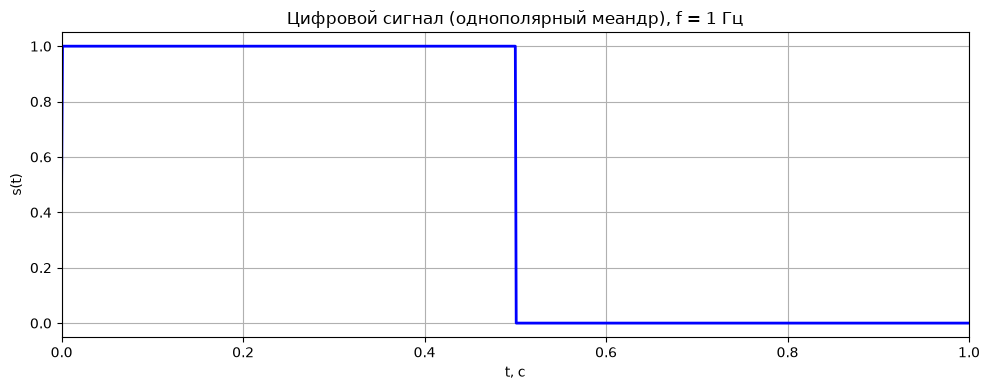

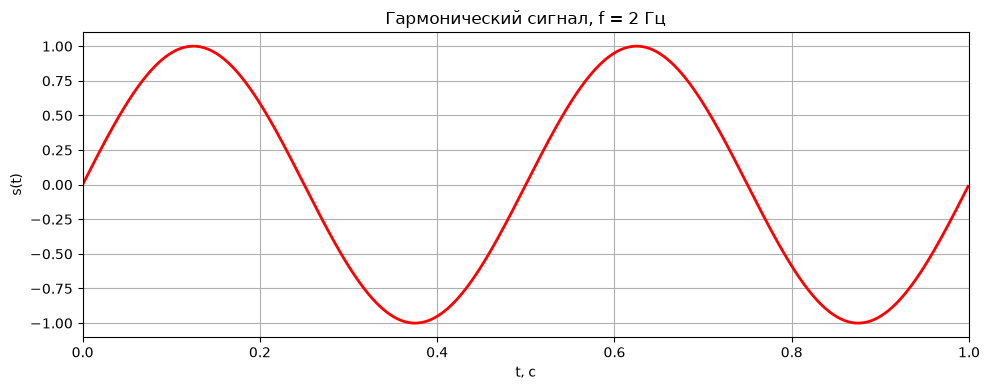

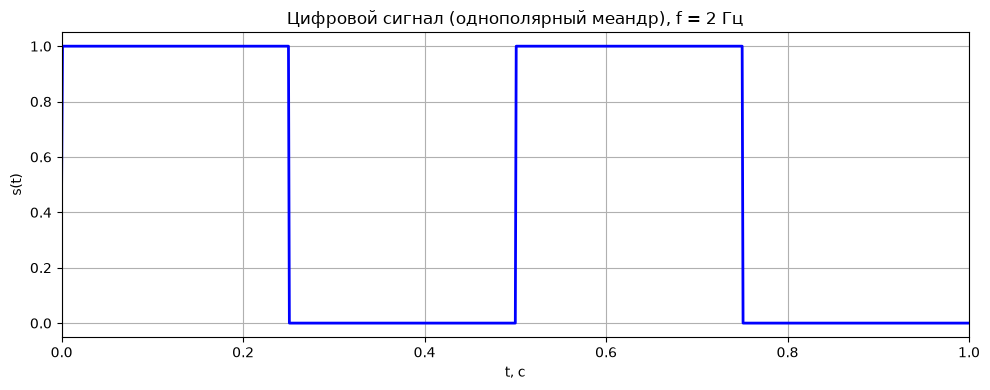

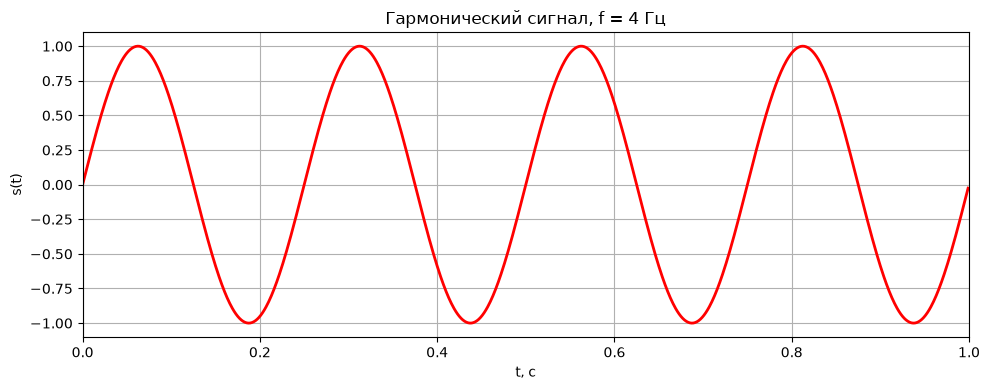

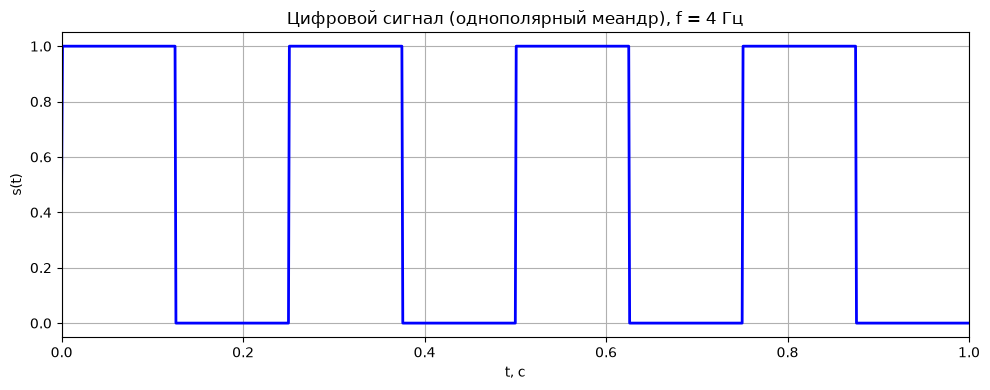

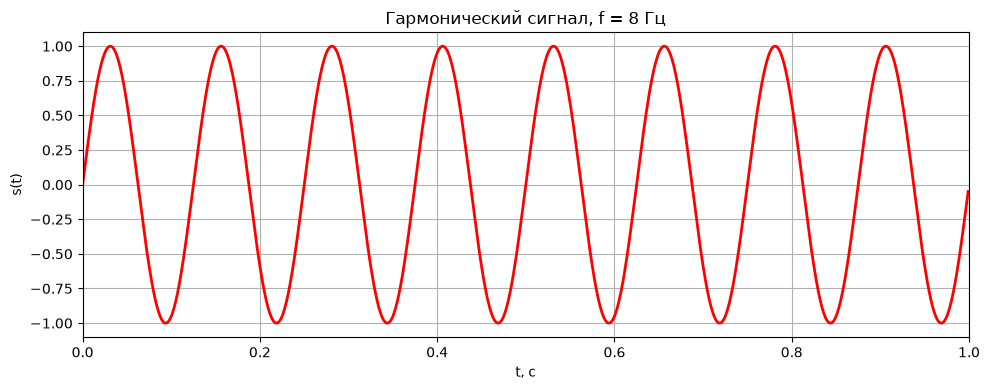

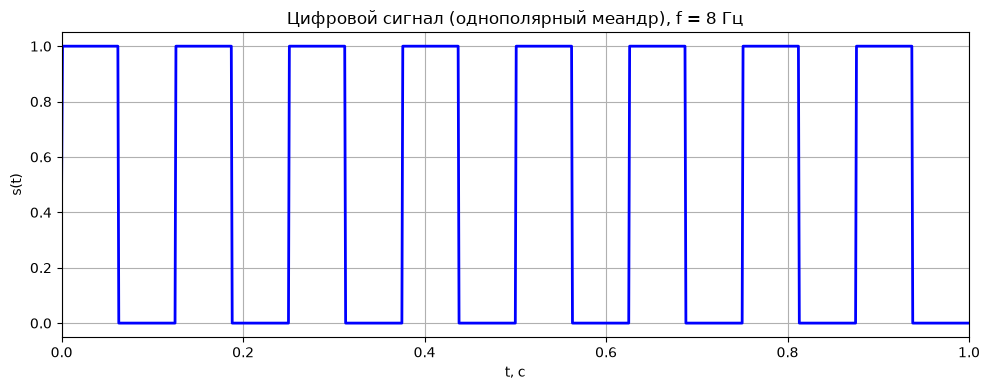

In [65]:
import matplotlib.pyplot as plt

    
for f in freqs:
    harmonic_signal_array = []
    for t in times:
        harmonic_signal_array.append(harmonic_signal(f, t, A))
    plt.figure(figsize=(10, 4))
    plt.plot(times, harmonic_signal_array, color='red', linewidth=2)
    plt.title(f'Гармонический сигнал, f = {f} Гц')
    plt.xlabel('t, с')
    plt.ylabel('s(t)')
    plt.xlim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'harmonic_signal_{f}Hz.png', dpi=150)
    
    digital_signal_array = []
    for t in times:
        digital_signal_array.append(digital_signal(f, t, A))
    plt.figure(figsize=(10, 4))
    plt.plot(times, digital_signal_array, color='blue', linewidth=2)
    plt.title(f'Цифровой сигнал (однополярный меандр), f = {f} Гц')
    plt.xlabel('t, с')
    plt.ylabel('s(t)')
    plt.xlim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'digital_signal_{f}Hz.png', dpi=150)
    


### 3. Спектр для каждого сигнала
Спектр сигнала - это разложение сигнала по синусоидам разных частот, дискретное преобразование Фурье (ДПФ):


X[k] = сумма от n=0 до N - 1 ( x[n] * e^(−i * 2pi * k  * n / N) )


x[n] - отсчёты сигнала

k - индекс частоты (0, 1, 2, ..., N−1)

X[k] - комплексное число: его модуль даёт амплитуду, аргумент — фазу

N - число отсчётов

Соответственно, ниже представлена функция spectrum, выдающая спектр сигнала, где freqs_f - частоты, amplitudes - само разложение в спектр

In [66]:
def spectrum(x, fs):
    N = len(x)

    freqs_f = []    
    amplitudes = []

    for k in range(N // 2 + 1):
        re = 0.0
        im = 0.0

        for n in range(N):
            angle = 2 * np.pi * k * n / N
            re += x[n] * np.cos(angle)
            im -= x[n] * np.sin(angle)
            
        amp = np.sqrt(re * re + im * im) / N
        
        if k != 0:
            amp *= 2

        freq = k * fs / N

        freqs_f.append(freq)
        amplitudes.append(amp)

    return freqs_f, amplitudes

А здесь представлено построение графиков спектров сигналов

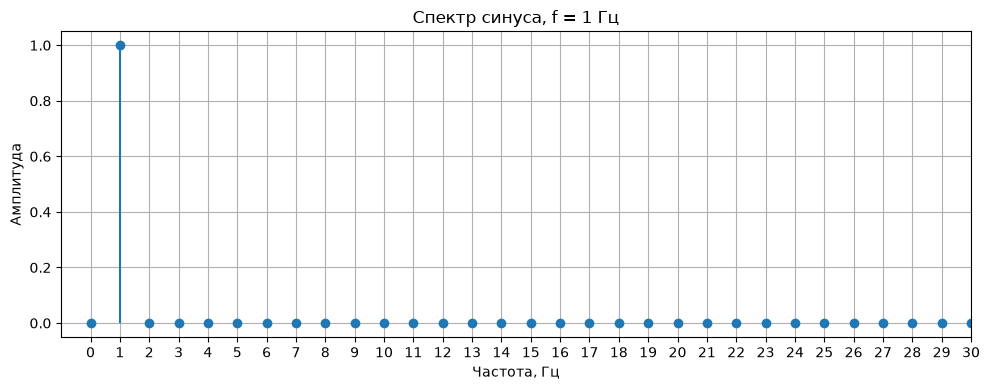

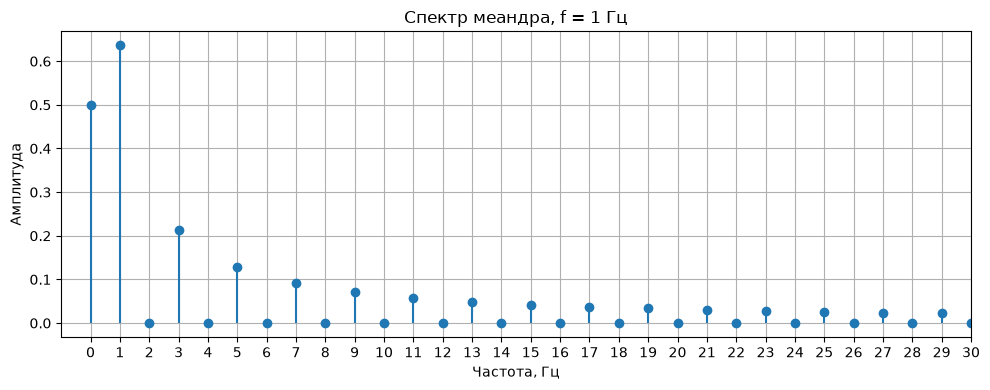

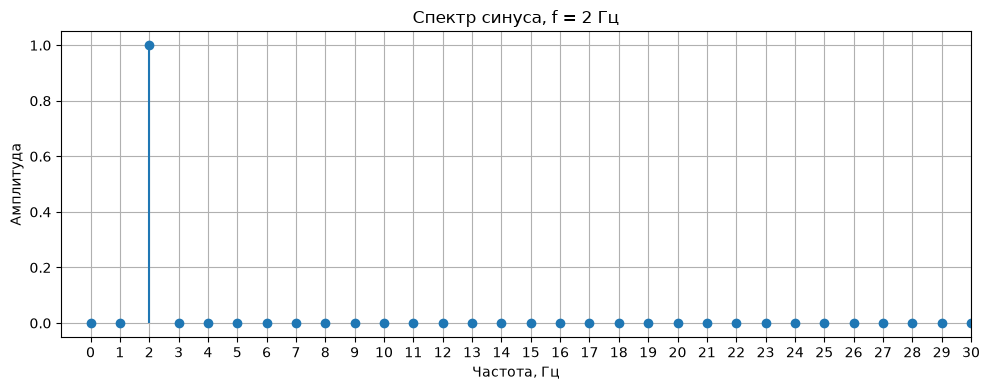

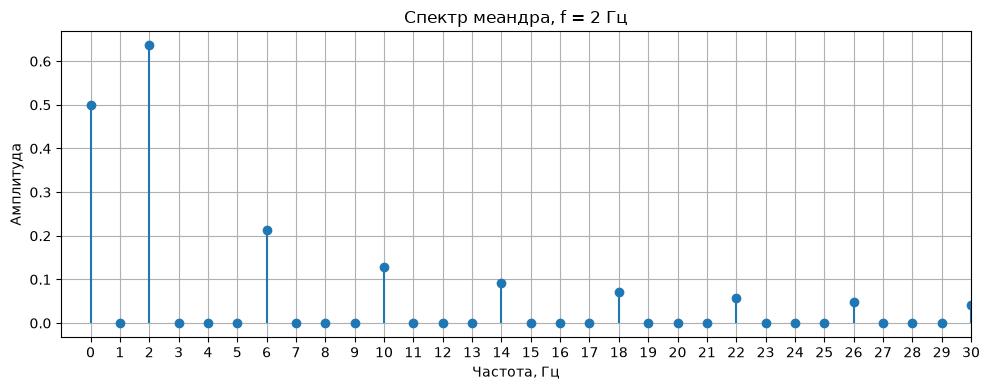

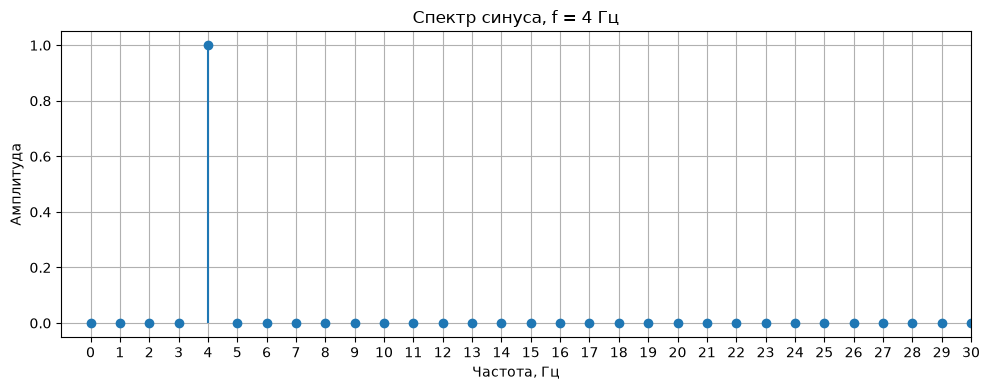

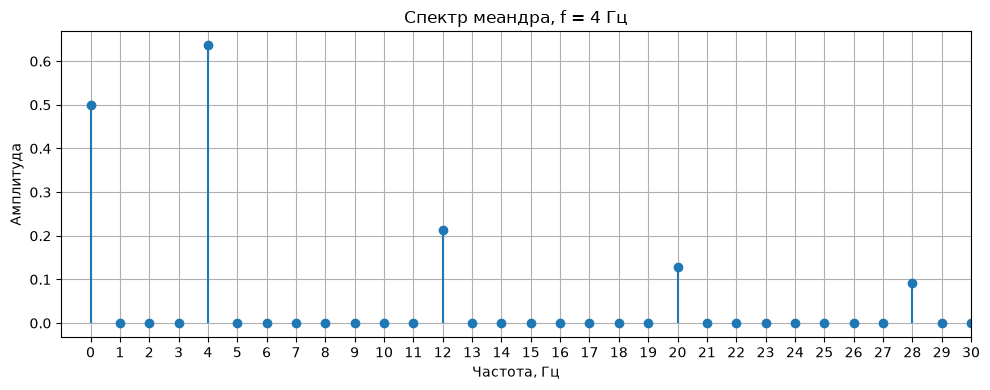

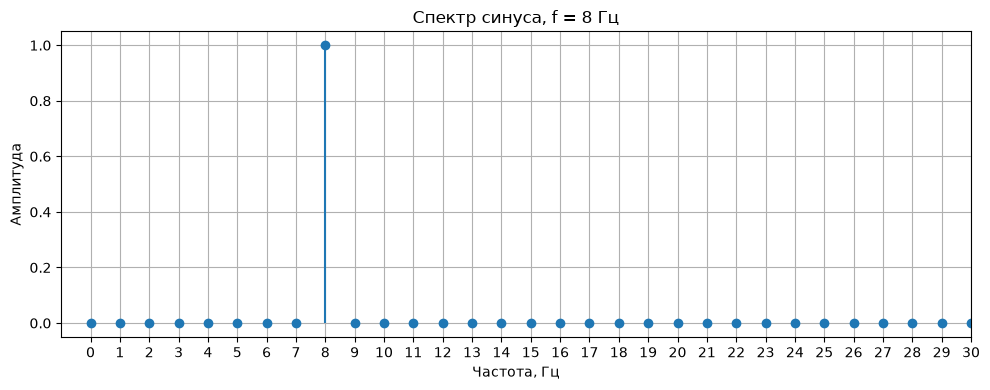

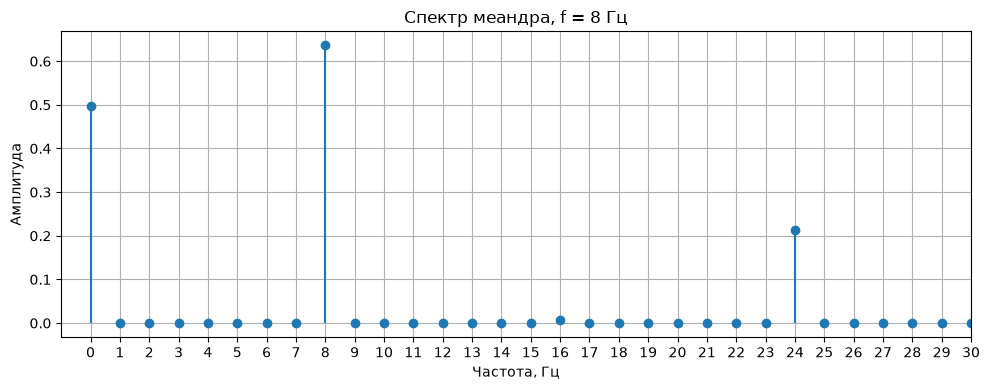

In [67]:
for f in freqs:
    harmonic_signal_array = []
    for t in times:
        harmonic_signal_array.append(harmonic_signal(f, t, A))
        
    fr, S = spectrum(harmonic_signal_array, fs)
    plt.figure(figsize=(10, 4))
    plt.stem(fr, S, basefmt=" ")
    plt.title(f'Спектр синуса, f = {f} Гц')
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда')
    plt.xlim(-1, 30)
    plt.xticks(np.arange(0, 31, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'spectrum_harmonic_{f}Hz.png', dpi=150)
    plt.close()
    
    
    digital_signal_array = []
    for t in times:
        digital_signal_array.append(digital_signal(f, t, A))

    fr, Q = spectrum(digital_signal_array, fs)
    plt.figure(figsize=(10, 4))
    plt.stem(fr, Q, basefmt=" ")
    plt.title(f'Спектр меандра, f = {f} Гц')
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда')
    plt.xlim(-1, 30)
    plt.xticks(np.arange(0, 31, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'spectrum_digital_{f}Hz.png', dpi=150)
    plt.close()

### Вывод
В работе получены спектры гармонического и цифрового (однополярный меандр) сигналов на частотах 1, 2, 4 и 8 Гц с помощью прямого ДПФ. Показано, что спектр синуса содержит одну гармонику на частоте сигнала, а спектр однополярного меандра - постоянную составляющую на частоте 0 и нечётные гармоники 1 * f, 3 * f, 5 * f, ... с амплитудами 2 * A / (pi * n).